In [15]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph
from IPython.display import Image, display

In [16]:
class AgentState(TypedDict): #Our state schema
    name: str
    age: int
    skills: List[str]
    final: str

In [17]:
def name_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence that gets the name and appends it to the final field"""
    state["final"] = f"{state['name']}, welcome to the system!"
    return state

def age_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence that gets the age and appends it to the final field"""
    state["final"] += f" You are {state['age']} years old!"
    return state

def skills_node(state: AgentState) -> AgentState:
    """This is the third node of our sequence that gets the skills and appends it to the final field"""

    skills_stringified = None
    for index, value in enumerate(state['skills']):
        if(index==0):
            skills_stringified = value
        elif(index==(len(state['skills'])-1)):
            skills_stringified += f", and {value}"
        else:
            skills_stringified += f", {value}"

    state["final"] += f" You have skills in `{skills_stringified}`"
    return state

In [18]:
graph = StateGraph(AgentState)
graph.add_node("name_node",name_node)
graph.add_node("age_node",age_node)
graph.add_node("skills_node",skills_node)

graph.add_edge("name_node","age_node")
graph.add_edge("age_node","skills_node")
graph.set_entry_point("name_node")
graph.set_finish_point("skills_node")
app = graph.compile()

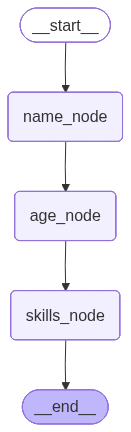

In [19]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"name":"bwando","age":45,"skills":["sleeping","eating","farting"]})

In [21]:
result["final"]

'bwando, welcome to the system! You are 45 years old! You have skills in `sleeping`'